# Spherical Harmonics and Signals on the Sphere

Spherical harmonics form an orthonormal basis on $\mathbb S^2$:
$$
f(\theta,\phi)=\sum_{\ell=0}^{\infty}\sum_{m=-\ell}^{\ell} c_{\ell m}Y_\ell^m(\theta,\phi).
$$
We use low-order real harmonics to synthesize and visualize a band-limited signal.

Spherical harmonics $Y_\ell^m$ diagonalize the Laplace--Beltrami operator on the sphere and provide a Fourier basis for directional data. Degree $\ell$ controls angular frequency. Reconstructions and energy spectra show how truncation smooths a signal and organizes multiscale content.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/spherical-harmonics-signals/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/spherical-harmonics-signals") if Path("python/spherical-harmonics-signals").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Spherical Harmonics and Signals on the Sphere**, with equations and plots designed to expose both the model and the numerical behavior.


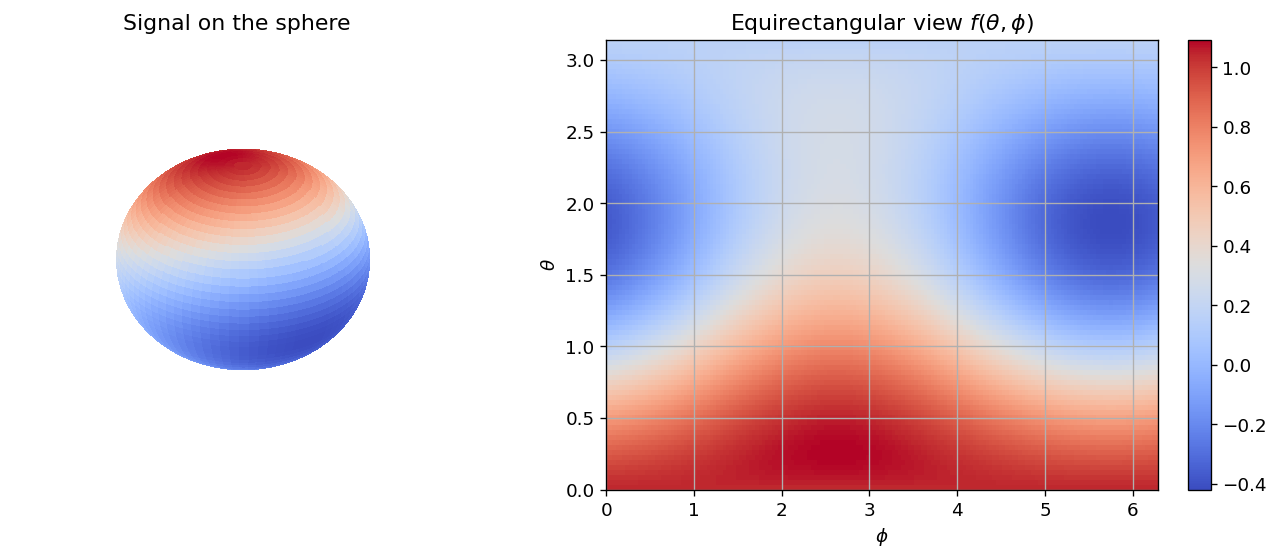

In [2]:
n_theta, n_phi = 90, 170
theta = np.linspace(0, np.pi, n_theta)
phi = np.linspace(0, 2*np.pi, n_phi)
Th, Ph = np.meshgrid(theta, phi, indexing="ij")

# Real low-order harmonics (up to l=2) in closed form.
Y00 = 0.5 / np.sqrt(np.pi) * np.ones_like(Th)
Y10 = np.sqrt(3/(4*np.pi)) * np.cos(Th)
Y11c = np.sqrt(3/(4*np.pi)) * np.sin(Th) * np.cos(Ph)
Y11s = np.sqrt(3/(4*np.pi)) * np.sin(Th) * np.sin(Ph)
Y20 = np.sqrt(5/(16*np.pi)) * (3*np.cos(Th)**2 - 1)

f = 0.8*Y00 + 0.9*Y10 - 0.7*Y11c + 0.4*Y11s + 0.6*Y20

X = np.sin(Th) * np.cos(Ph)
Y = np.sin(Th) * np.sin(Ph)
Z = np.cos(Th)

fig = plt.figure(figsize=(11.5, 4.8))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X, Y, Z, facecolors=plt.cm.coolwarm((f - f.min())/(f.max() - f.min() + 1e-12)),
                 rstride=2, cstride=2, linewidth=0, antialiased=False, shade=False)
ax1.set_title("Signal on the sphere")
ax1.set_axis_off()

ax2 = fig.add_subplot(1, 2, 2)
im = ax2.imshow(f, origin="lower", aspect="auto", cmap="coolwarm",
                extent=[0, 2*np.pi, 0, np.pi])
ax2.set_title(r"Equirectangular view $f(\theta,\phi)$")
ax2.set_xlabel(r"$\phi$")
ax2.set_ylabel(r"$\theta$")
fig.colorbar(im, ax=ax2, fraction=0.046)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- J. D. Driscoll, D. M. Healy, "Computing Fourier Transforms and Convolutions on the 2-Sphere", Adv. Appl. Math., 1994.
- F. J. Simons, F. A. Dahlen, M. A. Wieczorek, "Spatiospectral Concentration on a Sphere", SIAM Review, 2006.
- S. Helgason, *Groups and Geometric Analysis*, AMS, 2000.
